# getting sentinel 3 SLT data from `openeo`

This is largely based on the tutorial from openeo, see https://openeo.org/documentation/1.0/python/#installation


In [171]:
import openeo
import pandas as pd
import geopandas as gpd
import numpy as np
import shapely as shp
import xarray as xr
import rasterio
import matplotlib.pyplot as plt
import cartopy

In [172]:
# connect to https://openeo.dataspace.copernicus.eu
connection = openeo.connect("https://openeofed.dataspace.copernicus.eu")

# this could instead also be another openeo backend provider (kind of a website or data portal where all the data collections are stored)
# all the backend provider can be found here: https://hub.openeo.org/
# example for GEE, which is also a backend for openeo:

# connection = openeo.connect("https://earthengine.openeo.org")

In [173]:
connection.list_collection_ids() # lists all the collections providd by the back-end
S3_LST_L2 = 'SENTINEL3_SLSTR_L2_LST' # there is indeed the dataset we need. I just save the name here

In [174]:
# this establishes the connection and then stores it so that I do not need to login everytime I run the notebook

connection.authenticate_oidc_device(
    provider_id="CDSE",
    store_refresh_token=True
)

# username: felician.heim@posteo.de
# password: SAR_now12calv#

Visit https://identity.dataspace.copernicus.eu/auth/realms/CDSE/device?user_code=KFTJ-IJZP 📋 to authenticate.

✅ Authorized successfully

<Connection to 'https://openeofed.dataspace.copernicus.eu/openeo/1.2/' with OidcBearerAuth>

# Explore dataset and get S3 L2 LST product
First I can explore the dataset I am interested in:


In [175]:
connection.describe_collection(S3_LST_L2) # product name had been saved earlier

{'cube:dimensions': {'bands': {'type': 'bands',
   'values': ['LST',
    'LST_uncertainty',
    'exception',
    'confidence_in',
    'sunAzimuthAngles',
    'sunZenithAngles',
    'viewAzimuthAngles',
    'viewZenithAngles']},
  't': {'extent': ['2016-04-17T11:33:13Z', None],
   'step': 'P2D',
   'type': 'temporal'},
  'x': {'axis': 'x',
   'extent': [-180, 180],
   'reference_system': 4326,
   'step': 0.008928571428571,
   'type': 'spatial'},
  'y': {'axis': 'y',
   'extent': [-90, 90],
   'reference_system': 4326,
   'step': 0.008928571428571,
   'type': 'spatial'}},
 'description': '*Experimental* Daily global Sentinel-3 land surface temperature at 1km resolution. Land surface temperature is defined as the effective radiometric temperature of the Earth\'s surface "skin" in the instrument field of view. Here, "skin" is referring to the top surface in bare soil conditions and to the effective emitting temperature of vegetation "canopies" as determined from a view of the top of a canopy.\n This product is derived from the SLSTR (Sea and Land Surface Temperature Radiometer) instrument on board the Sentinel-3 satellite.\n\n Multiple observations may be available per day, we recommend temporal aggregation to create daily composites. ',
 'experimental': True,
 'extent': {'spatial': {'bbox': [[0, 0, 0, 0]]},
  'temporal': {'interval': [[None, None]]}},
 'id': 'SENTINEL3_SLSTR_L2_LST',
 'keywords': ['COPERNICUS', 'ESA', 'Sentinel-3', 'SLSTR'],
 'license': 'proprietary',
 'links': [{'href': 'https://openeo.dataspace.copernicus.eu/openeo/1.1/collections/SENTINEL3_SLSTR_L2_LST/queryables',
   'rel': 'http://www.opengis.net/def/rel/ogc/1.0/queryables',
   'type': 'application/schema+json'},
  {'href': 'https://openeofed.dataspace.copernicus.eu/openeo/1.2/collections',
   'rel': 'root'},
  {'href': 'https://openeofed.dataspace.copernicus.eu/openeo/1.2/collections',
   'rel': 'parent'},
  {'href': 'https://openeofed.dataspace.copernicus.eu/openeo/1.2/collections/SENTINEL3_SLSTR_L2_LST',
   'rel': 'self'}],
 'stac_extensions': ['https://stac-extensions.github.io/datacube/v2.2.0/schema.json',
  'https://stac-extensions.github.io/eo/v1.1.0/schema.json'],
 'stac_version': '1.0.0',
 'summaries': {'bands': [{'eo:common_name': 'surface_temperature',
    'name': 'LST'},
   {'eo:common_name': 'surface_temperature_standard_error',
    'name': 'LST_uncertainty'},
   {'name': 'exception'},
   {'name': 'confidence_in'},
   {'name': 'sunAzimuthAngles'},
   {'name': 'sunZenithAngles'},
   {'name': 'viewAzimuthAngles'},
   {'name': 'viewZenithAngles'}],
  'eo:bands': [{'aliases': ['LST_in:LST'],
    'common_name': 'surface_temperature',
    'gsd': 1000,
    'name': 'LST',
    'offset': 290,
    'scale': 0.0020000001,
    'unit': 'K'},
   {'aliases': ['LST_in:LST_uncertainty'],
    'common_name': 'surface_temperature_standard_error',
    'gsd': 1000,
    'name': 'LST_uncertainty',
    'offset': 0,
    'scale': 0.0020000001,
    'unit': 'K'},
   {'aliases': ['LST_in:exception'],
    'gsd': 1000,
    'name': 'exception',
    'offset': 0,
    'scale': 1},
   {'aliases': ['flags_in:confidence_in'],
    'description': 'quality control flags including summary_cloud flag',
    'gsd': 1000,
    'name': 'confidence_in'},
   {'aliases': ['geometry_tn:solar_azimuth_tn'],
    'description': 'nadir view solar azimuth angles',
    'gsd': 1000,
    'name': 'sunAzimuthAngles',
    'unit': 'deg'},
   {'aliases': ['geometry_tn:solar_zenith_tn'],
    'description': 'nadir view solar zenith angles',
    'gsd': 1000,
    'name': 'sunZenithAngles',
    'unit': 'deg'},
   {'aliases': ['geometry_tn:sat_azimuth_tn'],
    'description': 'nadir view satellite azimuth angles',
    'gsd': 1000,
    'name': 'viewAzimuthAngles',
    'unit': 'deg'},
   {'aliases': ['geometry_tn:sat_zenith_tn'],
    'description': 'nadir view satellite zenith angles',
    'gsd': 1000,
    'name': 'viewZenithAngles',
    'unit': 'deg'}],
  'federation:backends': ['cdse'],
  'raster:bands': [{},
   {},
  

It would be really important to mask out clouds - so is there anything to do this?


There is a concept called "cubes" in openeo too, which describes the data I want to access with information on the sensor/product name, spatial extend, temperal range, bands/layers and cloud cover etc. 

In [176]:
# read shoreline of lake
lake = gpd.read_file(r'C:\Users\Lenovo\Documents\GEUS_internship\LWST_estimation_project\lake_polygons\lake_6_shoreline_shp\lake_shoreline.shp')
 #lake.crs --> EPSG 4326 --> fine

print(lake.crs)

 # get bounding box:
bbox = lake.bounds
bbox.minx[0]


EPSG:4326


np.float64(-49.781536044988435)

### define the cube with data to download
I will download the following bands:
- `LST` - the land surface temperature band
- `LST_uncertainty` - land surface tempetayure uncertainty estimate
- `exception` - the band where any instrument failure is recorded - all values should be used as mask (masked out)
- `confidence_in` - there is a bit number 2^14 which encodes apparently a cloud mask


In [177]:
from pathlib import Path

output_dir = Path("data/S3_LST_L2")
output_dir.mkdir(parents=True, exist_ok=True)

for year in range(2017, 2026):

    print(f"\nStarting {year}...")

    cube = connection.load_collection(
        "SENTINEL3_SLSTR_L2_LST",

        spatial_extent={
            "west": bbox.minx[0],
            "south": bbox.miny[0],
            "east": bbox.maxx[0],
            "north": bbox.maxy[0],
            "crs": "EPSG:4326",
        },

        temporal_extent=[
            f"{year}-01-01",
            f"{year}-12-31",
        ],

        bands=[
            "LST",
            "LST_uncertainty",
            "exception",
            "confidence_in",
        ],
    )

    job = cube.execute_batch(
        title=f"S3_LST_L2_{year}",
        outputfile=f"S3_LST_L2_{year}.nc",
    )

    print(f"Job submitted: {job.job_id}")

    job.start_and_wait()

    print(f"Job finished: {year}")

    results = job.get_results()

    results.download_files(str(output_dir))

    print(f"Downloaded {year}")


Starting 2017...
0:00:00 Job 'cdse-j-260821233353429b855e87bb2ef83e71': send 'start'
0:00:02 Job 'cdse-j-260821233353429b855e87bb2ef83e71': queued (progress 0%)
0:00:07 Job 'cdse-j-260821233353429b855e87bb2ef83e71': queued (progress 0%)
0:00:14 Job 'cdse-j-260821233353429b855e87bb2ef83e71': queued (progress 0%)
0:00:22 Job 'cdse-j-260821233353429b855e87bb2ef83e71': running (progress N/A)
0:00:32 Job 'cdse-j-260821233353429b855e87bb2ef83e71': running (progress N/A)
0:00:45 Job 'cdse-j-260821233353429b855e87bb2ef83e71': running (progress N/A)
0:01:00 Job 'cdse-j-260821233353429b855e87bb2ef83e71': running (progress N/A)
0:01:20 Job 'cdse-j-260821233353429b855e87bb2ef83e71': running (progress N/A)
0:01:44 Job 'cdse-j-260821233353429b855e87bb2ef83e71': running (progress N/A)
0:02:14 Job 'cdse-j-260821233353429b855e87bb2ef83e71': running (progress N/A)
0:02:52 Job 'cdse-j-260821233353429b855e87bb2ef83e71': running (progress N/A)
0:03:39 Job 'cdse-j-260821233353429b855e87bb2ef83e71': running

In [162]:
# do a batch process:

# define a fresh cube, with long time series (full)
cube = connection.load_collection(
    'SENTINEL3_SLSTR_L2_LST',
    spatial_extent={
        "west": bbox.minx[0],
        "south": bbox.miny[0],
        "east": bbox.maxx[0],
        "north": bbox.maxy[0],
        "crs": "EPSG:4326",},
    temporal_extent=[
        "2017-01-01",
        "2025-12-31",],
    bands=["LST", # temperature
    "LST_uncertainty", # uncertainty
    "exception", # sensor failure mask
    'confidence_in']) # includes cloud mask encoded in bits (cloud seems to be 2^14)

job = cube.execute_batch(
    title="S3_LST_L2_2017_2025",
    outputfile="S3_LST_L2_2017_2025.nc"
)

job.start_and_wait()

results = job.get_results()
results.download_files("data")

0:00:00 Job 'cdse-j-2608211523584f5d8a6dbdbaded0ba36': send 'start'
0:00:02 Job 'cdse-j-2608211523584f5d8a6dbdbaded0ba36': queued (progress 0%)
0:00:07 Job 'cdse-j-2608211523584f5d8a6dbdbaded0ba36': queued (progress 0%)
0:00:14 Job 'cdse-j-2608211523584f5d8a6dbdbaded0ba36': queued (progress 0%)
0:00:23 Job 'cdse-j-2608211523584f5d8a6dbdbaded0ba36': running (progress N/A)
0:00:33 Job 'cdse-j-2608211523584f5d8a6dbdbaded0ba36': running (progress N/A)
0:00:45 Job 'cdse-j-2608211523584f5d8a6dbdbaded0ba36': running (progress N/A)
0:01:01 Job 'cdse-j-2608211523584f5d8a6dbdbaded0ba36': running (progress N/A)
0:01:20 Job 'cdse-j-2608211523584f5d8a6dbdbaded0ba36': running (progress N/A)
0:01:45 Job 'cdse-j-2608211523584f5d8a6dbdbaded0ba36': running (progress N/A)
0:02:15 Job 'cdse-j-2608211523584f5d8a6dbdbaded0ba36': running (progress N/A)
0:02:52 Job 'cdse-j-2608211523584f5d8a6dbdbaded0ba36': running (progress N/A)
0:03:39 Job 'cdse-j-2608211523584f5d8a6dbdbaded0ba36': running (progress N/A)
0:

[WindowsPath('data/openEO.nc'), WindowsPath('data/job-results.json')]

### access now data for whole of 2018 including all other bands

In [ ]:
# open dataset
data = xr.open_dataset(r"data/2018/Sentinel-3_LST_L2_2018_all_bands2.nc")


In [134]:
# inspect the data set
print(data["LST"].attrs)
print(data["LST_uncertainty"].attrs)
print(data["exception"].attrs)
print(data["confidence_in"].attrs)

# unfortunately no units given! --> but this is included in the metadata:
#connection.describe_collection(S3_LST_L2) # product name had been saved earlier



{'long_name': 'LST', 'units': '', 'grid_mapping': 'crs'}
{'long_name': 'LST_uncertainty', 'units': '', 'grid_mapping': 'crs'}
{'long_name': 'exception', 'units': '', 'grid_mapping': 'crs'}
{'long_name': 'confidence_in', 'units': '', 'grid_mapping': 'crs'}


### try to get the loud mask and plot both together
If the integer in confidence_int is ≥ 16384 (which is the int way of writing bit 14), the pixel is considered cloudy.


In [ ]:
# get the unique levels
unique_vals = np.unique(data["confidence_in"])

# mask out cloudy pixels
cloudy = (data["confidence_in"] >= 2**14)
lst_cloud_free = data["LST"].where(~cloudy)

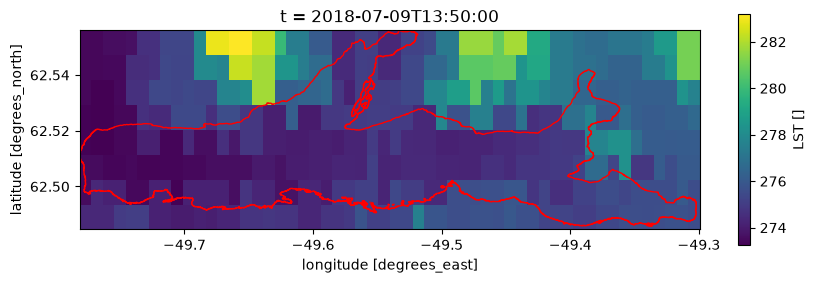

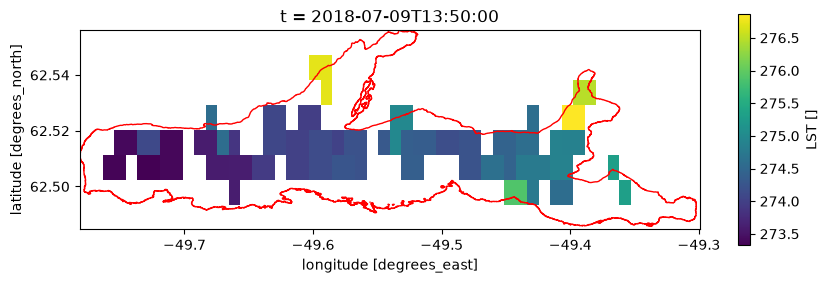

In [144]:
fig,ax=plt.subplots(figsize = (10, 3)) 
data["LST"].isel(t = 742).plot(ax=ax) 
lake.plot(ax=ax, facecolor='none', edgecolor = 'red') 
plt.show()

fig,ax=plt.subplots(figsize = (10, 3)) 
lst_cloud_free.isel(t = 742).plot(ax=ax) 
lake.plot(ax=ax, facecolor='none', edgecolor = 'red') 
plt.show()